# Name : Priyanshu Kumar Singh
# OASIS INFOBYTE DATA SCIENCE INTERNSHIP
# TASK 2 : Unemployment Analysis with Python

Objective : Identify the species of an iris
flower (Setosa, Versicolor, or Virginica) from its physical measurements, by training a machine learning classification model

Project Description:

This project focuses on predicting Iris flower species using machine learning techniques based on physical measurements of sepal and petal dimensions. Using Exploratory Data Analysis (EDA), we analyze feature distributions and compare performance across classification algorithms like Logistic Regression and Random Forest to determine the most accurate model for multi-class prediction.

In [1]:
#Loading the dataset

In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

print("Setup Complete!")

Setup Complete!


In [3]:
from sklearn import datasets
iris = datasets.load_iris()

In [4]:
print(iris.feature_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [5]:
print(iris.target_names)

['setosa' 'versicolor' 'virginica']


In [7]:
df = pd.DataFrame(
    iris.data,
    columns = iris.feature_names)

df["species"] = iris.target
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [8]:
df["species"] = df["species"].map({
    0:"setosa",
    1:"versicolor",
    2:"virginica"
})

df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [9]:
#EDA
#checking the dataset shape

In [10]:
df.shape

(150, 5)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 7.2 KB


In [12]:
#here, we found that:
#the dataset has 150 "rows(flower samples)", and 5 "columns(4 features + species)"
#the info gave us the no. of entries, col names, data types, and missing values

In [13]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

In [14]:
#this above result indicates 0 presence of any missing values

In [15]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [16]:
#the df.describe() gives the description of the samples' count, mean, std deviation, min, max, 25%, 50%,and 75% measures accordingly to the features based on which the model is to be trained

# Visualisation of pairplot showing feature distributions by species:

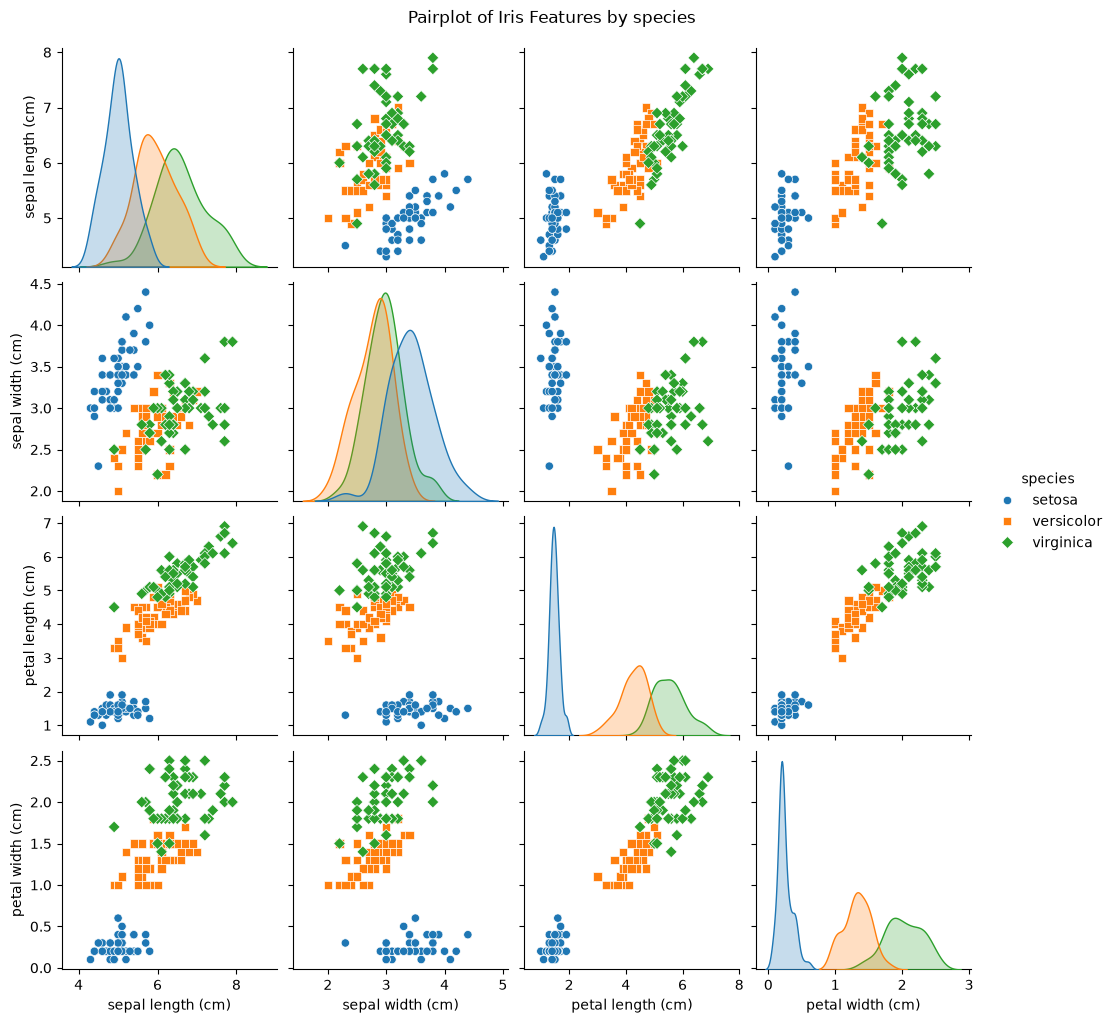

In [17]:
sns.pairplot(df, hue='species', markers = ["o", "s", "D"])
plt.suptitle("Pairplot of Iris Features by species", y = 1.02)
plt.show()

In [18]:
#the above plots show that the petal length and petal width separate the setosa species from versicolor and virginica

# Creating Box Plots for each feature

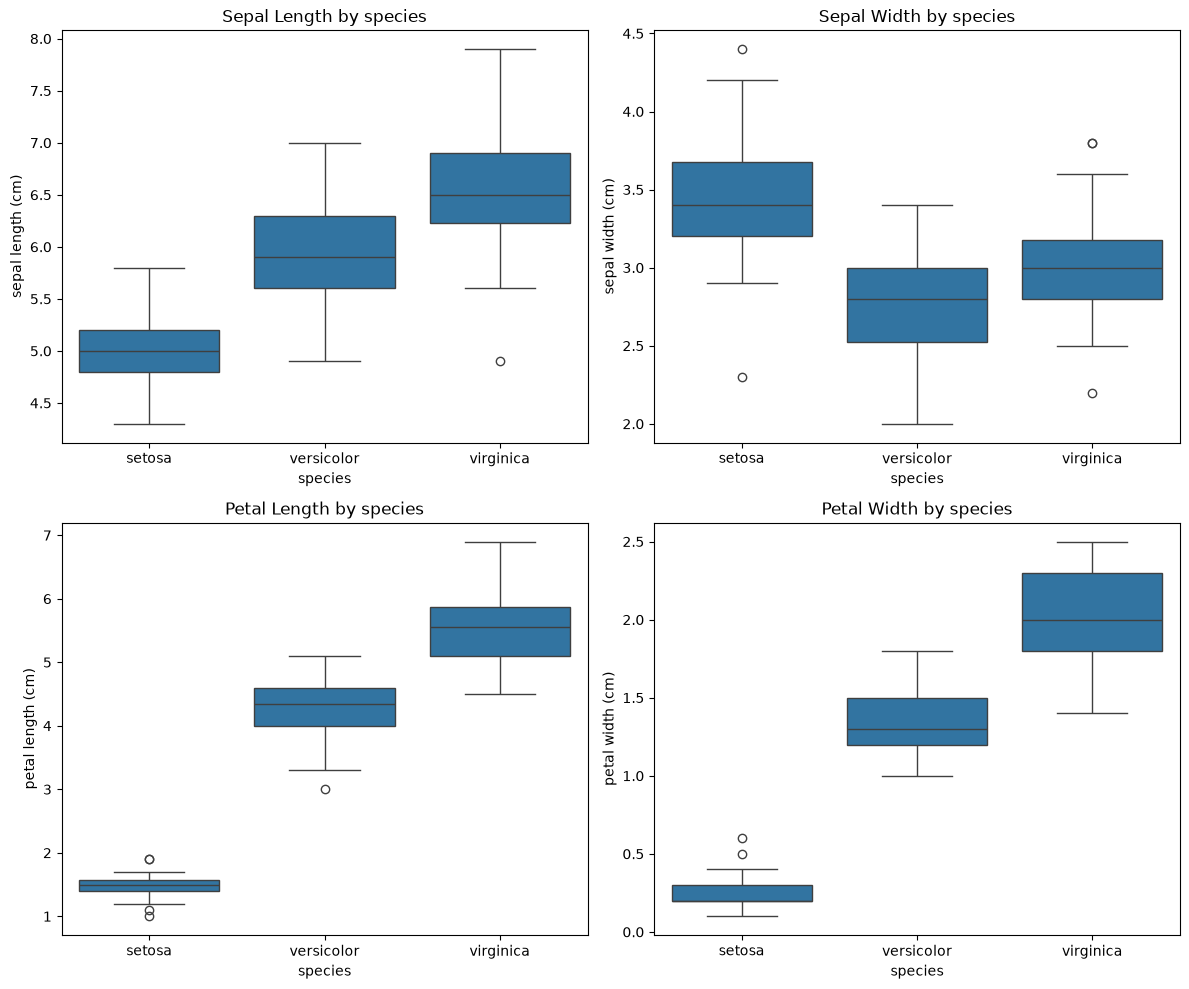

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.boxplot(x = 'species', y = 'sepal length (cm)', data=df, ax=axes[0, 0])
axes[0, 0].set_title('Sepal Length by species')

sns.boxplot(x='species', y='sepal width (cm)',data = df, ax=axes[0, 1])
axes[0, 1].set_title('Sepal Width by species')

sns.boxplot(x = 'species', y = 'petal length (cm)', data=df, ax=axes[1, 0])
axes[1, 0].set_title('Petal Length by species')

sns.boxplot(x = 'species', y = 'petal width (cm)', data=df, ax=axes[1, 1])
axes[1, 1].set_title('Petal Width by species')

plt.tight_layout()
plt.show()

In [20]:
#above box plots clearly show that the setosa has the most varying feature among the species

# Exploratory Data Analysis observations
 The box plots show that "Setosa" has distinctly smaller petal length and petal width compared to "Versicolor" and "Virginica".
 "Petal Length" and "Petal Width" are the most discriminative features for classifying the flower species.


# Feature Selection & Discriminative Analysis
Based on the Exploratory Data Analysis (EDA) visualizations and pairplots:

Most Discriminative Features:
Petal Length and Petal Width:These two features exhibit the strongest separation between the flower species. 'Iris-setosa' is completely linearly separable from the other two species based on petal dimensions alone.
    
Least Discriminative Feature:
Sepal Width: Shows significant overlap across 'versicolor' and 'virginica' distributions, making it the least effective single feature for separating species.

# Splitting the Training and Test samples into 80-20 ratio : 


In [22]:
# X contains the 4 measurement columns (features)
X = df.drop(columns=['species'])

# y contains only the target column (species)
y = df['species']

# Print shapes to verify
print("Features shape (X):", X.shape)
print("Target shape (y):", y.shape)

Features shape (X): (150, 4)
Target shape (y): (150,)


In [23]:
from sklearn.model_selection import train_test_split

# Split into 80% training set and 20% testing set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

Training features: (120, 4)
Testing features: (30, 4)


In [24]:
#upon splitting the samples, we get to know that the training features have dimension (120,4) , and that of the test feature are(30,4)

# Training of the Models

#Training Classifier Using Logistic Regression 

In [25]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the Logistic Regression model
model_lr = LogisticRegression(max_iter=200)
model_lr.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lr = model_lr.predict(X_test)
print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


#Training the Classifier using Random Forest

In [26]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest model
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = model_rf.predict(X_test)
print("Random Forest trained successfully!")

Random Forest trained successfully!


In [27]:
# Let's plot the comparison of the trained Logistic Regression model, and Random Forest model:

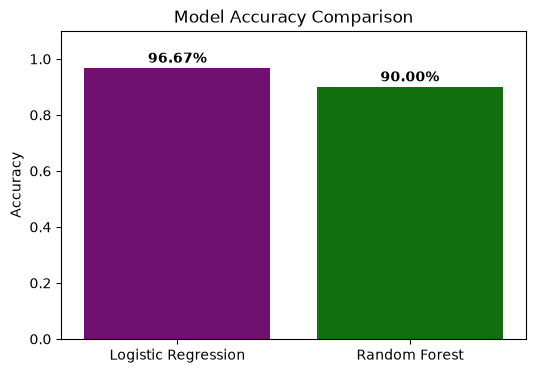

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

# Calculation of accuracies
acc_lr = accuracy_score(y_test, y_pred_lr)
acc_rf = accuracy_score(y_test, y_pred_rf)

# Plot 1: Model Accuracy Comparison 
plt.figure(figsize=(6, 4))
models = ['Logistic Regression', 'Random Forest']
accuracies = [acc_lr, acc_rf]

sns.barplot(
    x=models,
    y=accuracies,
    hue=models,
    palette=['purple', 'green'],
    legend=False,
)
plt.ylim(0, 1.1)
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.02, f"{acc:.2%}", ha='center', fontweight='bold')
plt.show()

In [29]:
#the above plot shows the plotted comparative illustration of the performances of the two models

# Evaluation of Models' Performances

In [30]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("=== LOGISTIC REGRESSION EVALUATION ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

print("\n" + "="*40 + "\n")

print("=== RANDOM FOREST EVALUATION ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

=== LOGISTIC REGRESSION EVALUATION ===
Accuracy: 0.9666666666666667

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


Confusion Matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


=== RANDOM FOREST EVALUATION ===
Accuracy: 0.9

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30


Confusion Mat

In [31]:
# Upon evaluation of the models' performances, the accuracy of the Logistic Regression is 96.67%, and that of Random Forest is 90%
# The classification report and the confusion matrices of the respective models are evaluated above

### Model Comparison and Best Model Declaration
Logistic Regression, which gave an accuracy of about 96.67%, is better than the Random Forest's accuracy(90%)
Also, the comparison of the confusion matrices and the overall classification reports of the both models, we may conclude that the Logistic Regression is better as bompared to the Random Forest Model, and hence, the best of the two models used.

### Conclusion:
Logistic Regression can be declared the best-performing model for this dataset since it achieved higher accuracy (96.67%) and gave better overall precision/recall scores across classes, as compared to that of Random Forest Because the Iris dataset is linearly separable for the Setosa species and small in scale, a simpler parametric linear model like Logistic Regression generalizes better without overfitting.